**Marginal statistics**

*Water level*

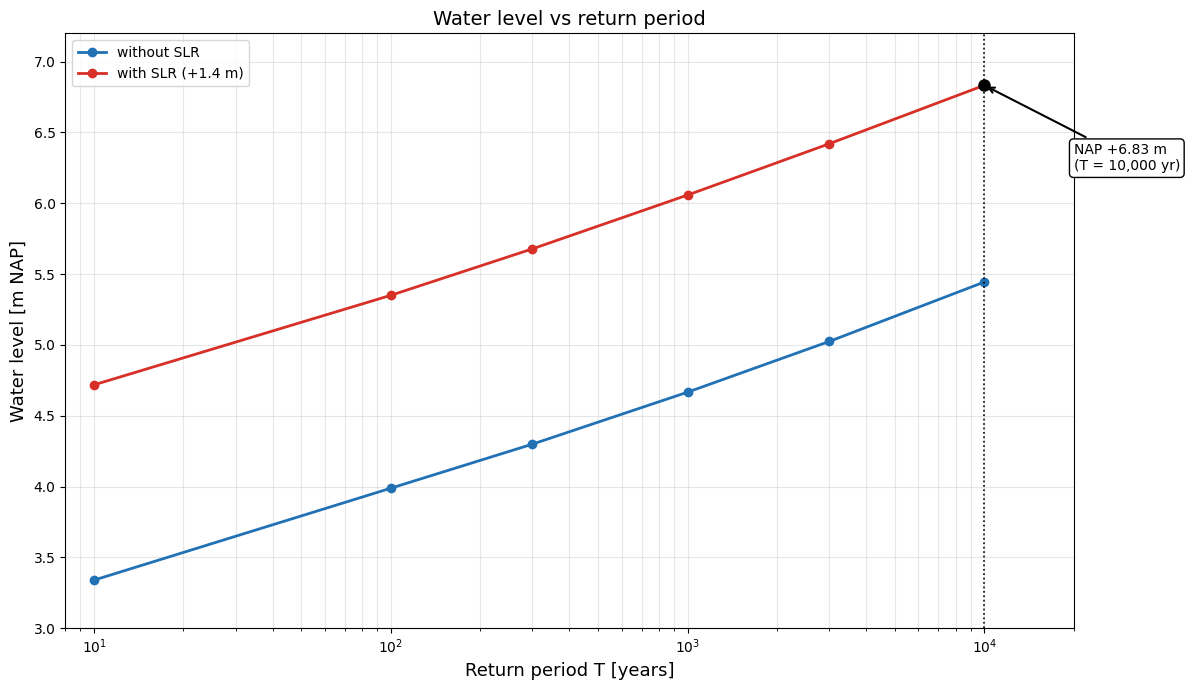


✓ Opgeslagen: waterlevel_return_period_1p4.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Return periods ──
T = np.array([10, 100, 300, 1000, 3000, 10000])

# ── Water levels [m + NAP] ──
data = {
    "without SLR":   np.array([3.339, 3.988, 4.299, 4.666, 5.024, 5.444]),
    "with SLR (+1.4 m)": np.array([4.718, 5.350, 5.678, 6.058, 6.420, 6.833]),
}

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#2171b5", "#d73027"]

for i, (scen, wl) in enumerate(data.items()):
    ax.plot(T, wl, '-o',
            color=colors[i],
            linewidth=2,
            markersize=6,
            label=scen)

# ── Verticale lijn T = 10.000 ──
ax.axvline(x=10000, color='black', linestyle=':', linewidth=1.2)

# ── Annotatie hoogste scenario ──
wl_10k = data["with SLR (+1.4 m)"][-1]
ax.plot(10000, wl_10k, 'ko', markersize=8)

ax.annotate(f'NAP +{wl_10k:.2f} m\n(T = 10,000 yr)',
            xy=(10000, wl_10k),
            xytext=(20000, wl_10k - 0.6),
            arrowprops=dict(arrowstyle='->', lw=1.5),
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor='black'))

# ── Opmaak ──
ax.set_xscale('log')
ax.set_xlabel('Return period T [years]', fontsize=13)
ax.set_ylabel('Water level [m NAP]', fontsize=13)
ax.set_title('Water level vs return period',
             fontsize=14)

ax.set_xlim(8, 20000)
ax.set_ylim(3.0, 7.2)

ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('waterlevel_return_period_1p4.png', dpi=200)
plt.show()


without SLR         : WL = 3.3 m NAP -> T = 8.7078 yr
with SLR (+1.4 m)   : WL = 3.3 m NAP -> T = 0.0571 yr


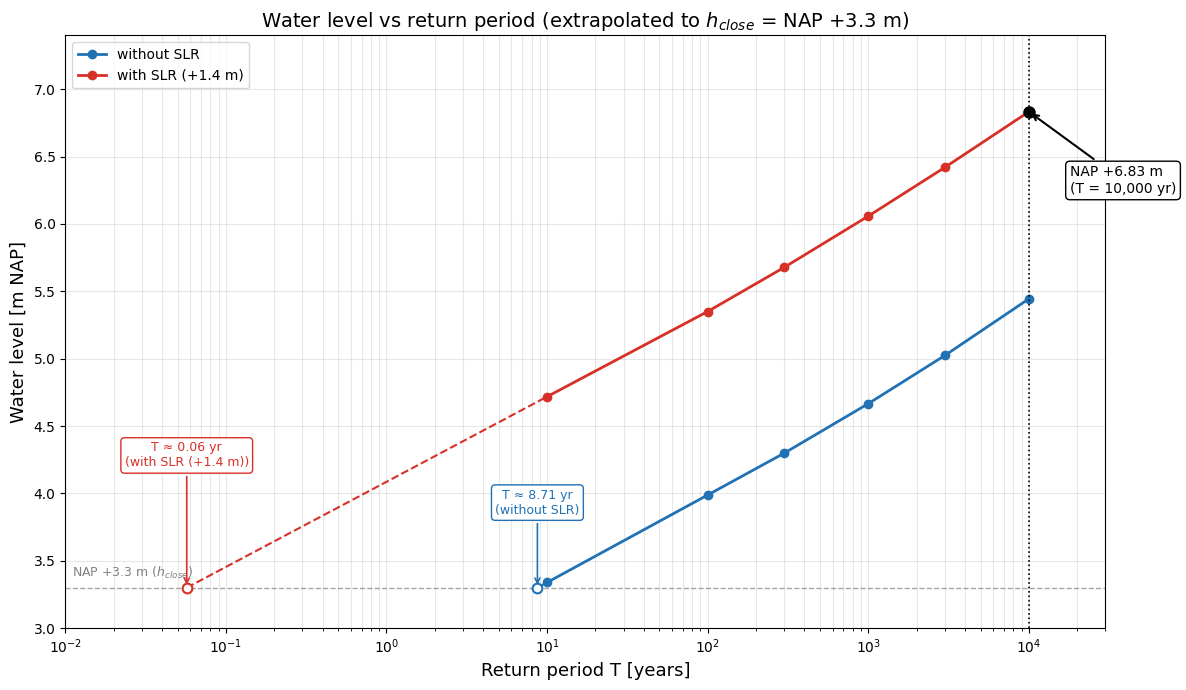

21 days


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Return periods ──
T = np.array([10, 100, 300, 1000, 3000, 10000])

# ── Water levels [m + NAP] ──
data = {
    "without SLR":       np.array([3.339, 3.988, 4.299, 4.666, 5.024, 5.444]),
    "with SLR (+1.4 m)": np.array([4.718, 5.350, 5.678, 6.058, 6.420, 6.833]),
}

# ── Doelwaterstand (operationeel sluitpeil h_close) ──
WL_TARGET = 3.3  # m + NAP

# ── Inverse extrapolatie: bij welke T hoort WL_TARGET? ──
# Waterstand ~ lineair in log10(T); gebruik de lokale helling van de twee
# onderste punten (T = 10 en T = 100), representatief voor de onderkant.
logT = np.log10(T)
T_at_target = {}
for scen, wl in data.items():
    slope_local = (wl[1] - wl[0]) / (logT[1] - logT[0])            # dWL / dlog10(T)
    logT_target = logT[0] + (WL_TARGET - wl[0]) / slope_local      # invert naar log10(T)
    T_at_target[scen] = 10 ** logT_target
    print(f"{scen:20s}: WL = {WL_TARGET} m NAP -> T = {T_at_target[scen]:.4f} yr")

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#2171b5", "#d73027"]

for i, (scen, wl) in enumerate(data.items()):
    # gemeten reeks
    ax.plot(T, wl, '-o', color=colors[i], linewidth=2, markersize=6, label=scen)
    # geëxtrapoleerd segment van (T_target, WL_TARGET) -> (T=10, laagste meetpunt)
    ax.plot([T_at_target[scen], T[0]], [WL_TARGET, wl[0]], '--',
            color=colors[i], linewidth=1.5)
    # geëxtrapoleerd punt op WL_TARGET (open marker)
    ax.plot(T_at_target[scen], WL_TARGET, 'o', color=colors[i],
            markerfacecolor='white', markersize=7, markeredgewidth=1.5, zorder=5)

# ── Horizontale lijn op doelwaterstand ──
ax.axhline(y=WL_TARGET, color='gray', linestyle='--', linewidth=1.0, alpha=0.7)
ax.text(0.011, WL_TARGET + 0.05, f'NAP +{WL_TARGET:.1f} m ($h_{{close}}$)',
        fontsize=9, color='gray', va='bottom')

# ── Verticale lijn T = 10.000 + annotatie hoogste scenario ──
ax.axvline(x=10000, color='black', linestyle=':', linewidth=1.2)
wl_10k = data["with SLR (+1.4 m)"][-1]
ax.plot(10000, wl_10k, 'ko', markersize=8)
ax.annotate(f'NAP +{wl_10k:.2f} m\n(T = 10,000 yr)',
            xy=(10000, wl_10k), xytext=(18000, wl_10k - 0.6),
            arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

# ── Annotaties: terugkeertijd bij WL_TARGET (beide scenario's) ──
for i, (scen, wl) in enumerate(data.items()):
    Tt = T_at_target[scen]
    ax.annotate(f'T \u2248 {Tt:.2f} yr\n({scen})',
                xy=(Tt, WL_TARGET),
                xytext=(Tt, WL_TARGET + 0.55 + 0.35 * i),
                arrowprops=dict(arrowstyle='->', lw=1.2, color=colors[i]),
                fontsize=9, color=colors[i], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=colors[i]))

# ── Opmaak ──
ax.set_xscale('log')
ax.set_xlabel('Return period T [years]', fontsize=13)
ax.set_ylabel('Water level [m NAP]', fontsize=13)
ax.set_title('Water level vs return period (extrapolated to $h_{close}$ = NAP +3.3 m)',
             fontsize=14)
ax.set_xlim(0.01, 30000)
ax.set_ylim(3.0, 7.4)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
# plt.savefig('waterlevel_return_period_3p3.png', dpi=200)
plt.show()

# print("\n\u2713 Opgeslagen: waterlevel_return_period_3p3.png")

print(f"{365*Tt:.0f} days")


RETURN PERIOD OF CLOSURE LEVEL (NAP +3.3 m)

2050: T = 3.8505 yr (1405 days)
2060: T = 2.8990 yr (1058 days)
2070: T = 2.1066 yr (769 days)
2080: T = 1.4259 yr (520 days)
2090: T = 0.9315 yr (340 days)
2100: T = 0.5668 yr (207 days)
2110: T = 0.4119 yr (150 days)
2120: T = 0.2691 yr (98 days)
2130: T = 0.1758 yr (64 days)
2140: T = 0.1190 yr (43 days)
2150: T = 0.0606 yr (22 days)


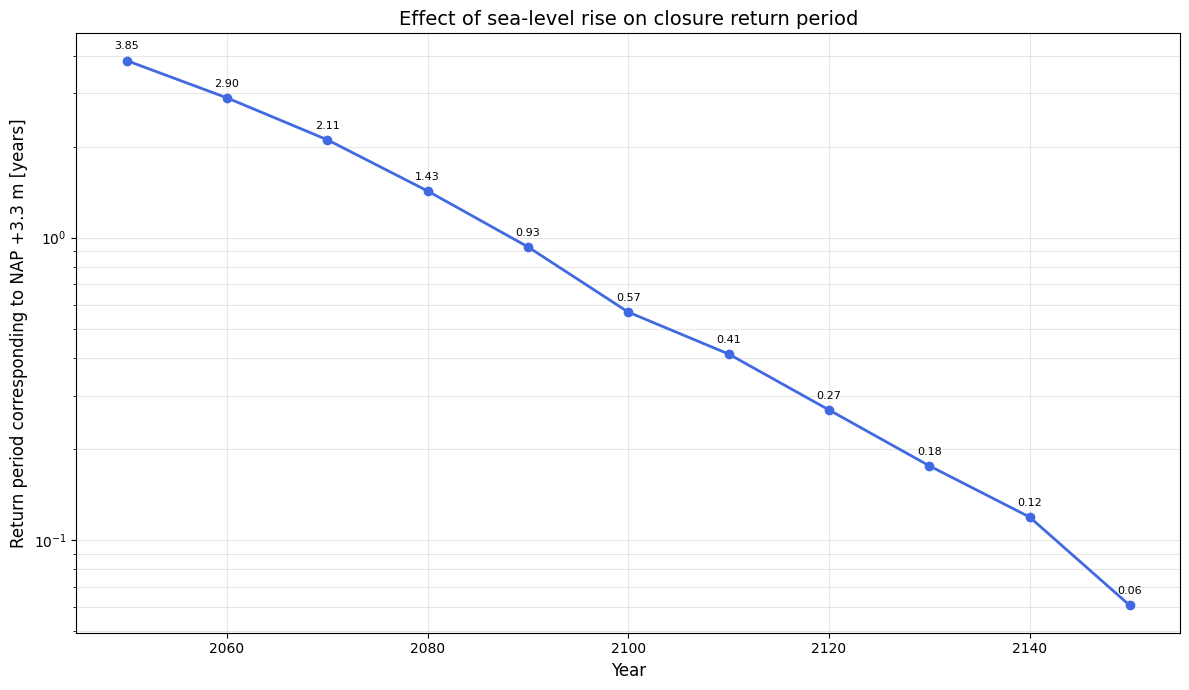

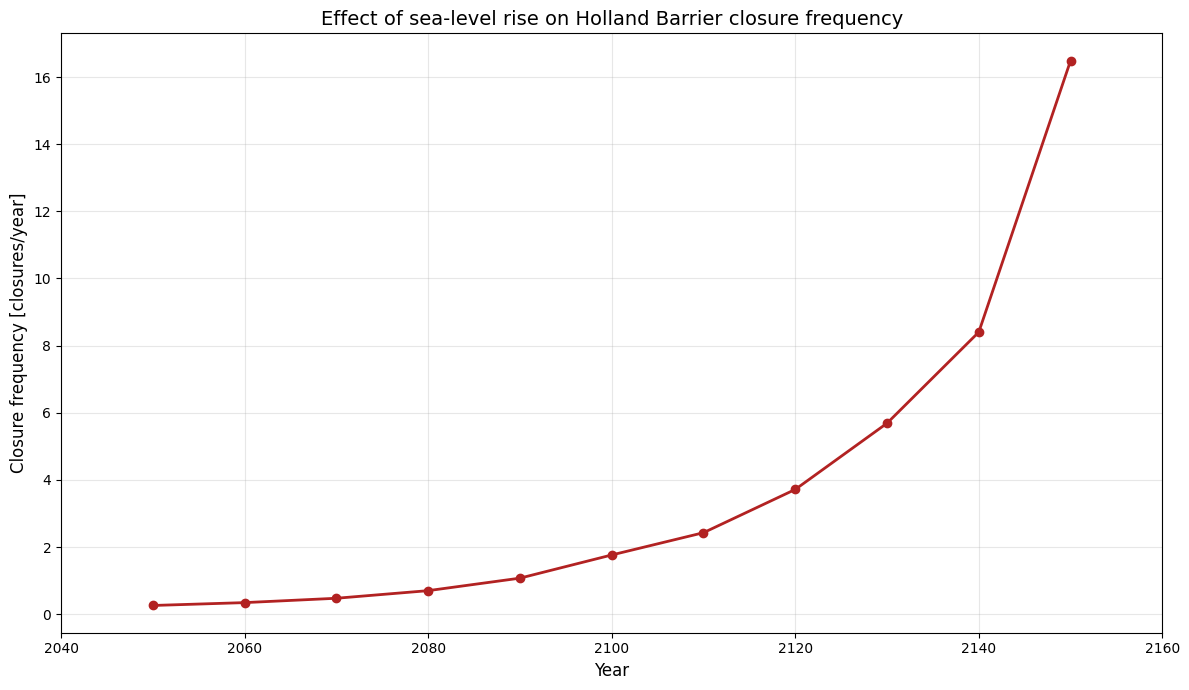


CUMULATIVE NUMBER OF CLOSURES

2050: 0.0 closures
2060: 3.0 closures
2070: 7.1 closures
2080: 13.0 closures
2090: 21.9 closures
2100: 36.1 closures
2110: 57.0 closures
2120: 87.7 closures
2130: 134.8 closures
2140: 205.2 closures
2150: 329.7 closures


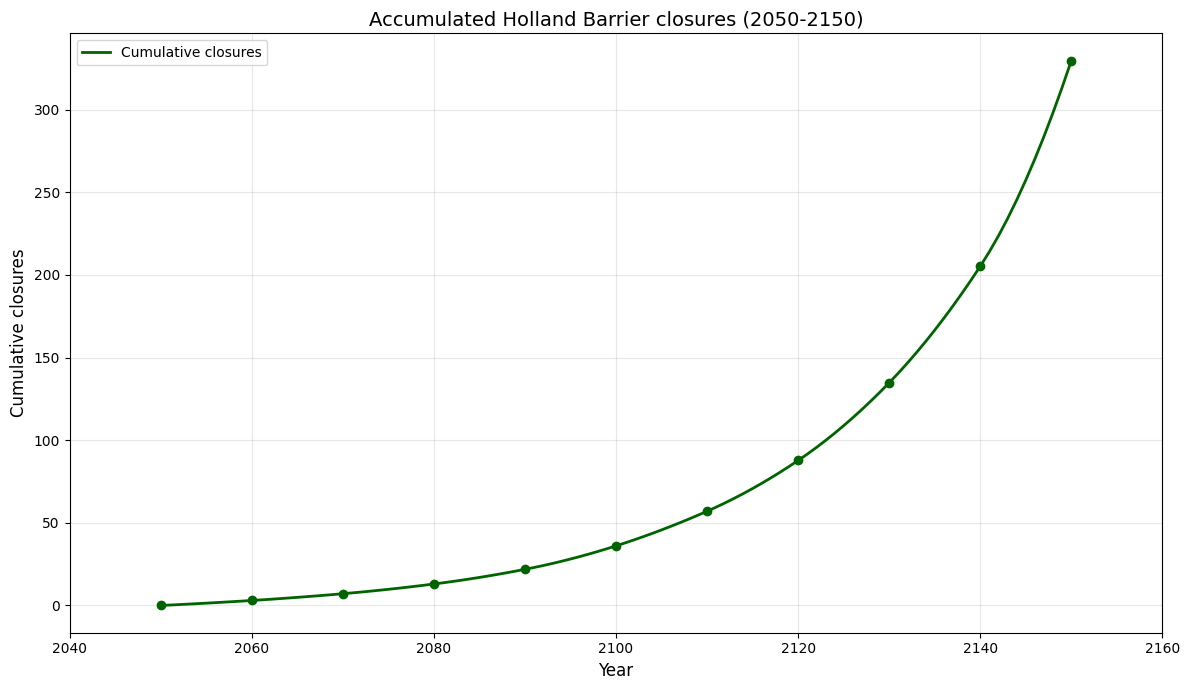


DESIGN VALUE

Total number of closures between 2050 and 2150 = 329.7
Rounded design value = 330 closures


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT
# ============================================================

# Return periods
T = np.array([10, 100, 300, 1000, 3000, 10000])

# Hydra-NL water levels without sea-level rise
WL_base = np.array([3.339, 3.988, 4.299, 4.666, 5.024, 5.444])

# Operational closure level
WL_TARGET = 3.30      # m NAP

# Sea-level rise scenario
slr = {
    2050: 0.23,
    2060: 0.31,
    2070: 0.40,
    2080: 0.51,
    2090: 0.63,
    2100: 0.77,
    2110: 0.86,
    2120: 0.98,
    2130: 1.10,
    2140: 1.21,
    2150: 1.40
}

# ============================================================
# FUNCTION
# ============================================================

def return_period_at_level(T, WL_curve, WL_target):
    """
    Determine return period corresponding to a given water level
    using log-linear extrapolation based on T=10 and T=100.
    """

    logT = np.log10(T)

    slope = (
        (WL_curve[1] - WL_curve[0]) /
        (logT[1] - logT[0])
    )

    logT_target = (
        logT[0]
        + (WL_target - WL_curve[0]) / slope
    )

    return 10**logT_target


# ============================================================
# RETURN PERIODS
# ============================================================

results = {}

for year, slr_value in slr.items():

    WL_curve = WL_base + slr_value

    results[year] = return_period_at_level(
        T,
        WL_curve,
        WL_TARGET
    )

years = np.array(sorted(results.keys()))
T_close = np.array([results[y] for y in years])

# ============================================================
# PRINT RETURN PERIODS
# ============================================================

print()
print("=" * 70)
print("RETURN PERIOD OF CLOSURE LEVEL (NAP +3.3 m)")
print("=" * 70)
print()

for year in years:

    T_year = results[year]

    print(
        f"{year}: "
        f"T = {T_year:.4f} yr "
        f"({365*T_year:.0f} days)"
    )

# ============================================================
# FIGURE 1
# RETURN PERIOD
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    years,
    T_close,
    '-o',
    color='royalblue',
    linewidth=2,
    markersize=6
)

for year, T_year in zip(years, T_close):

    ax.annotate(
        f"{T_year:.2f}",
        xy=(year, T_year),
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=8,
        ha='center'
    )

ax.set_yscale('log')

ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel(
    "Return period corresponding to NAP +3.3 m [years]",
    fontsize=12
)

ax.set_title(
    "Effect of sea-level rise on closure return period",
    fontsize=14
)

ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2
# CLOSURE FREQUENCY
# ============================================================

frequency = 1.0 / T_close

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    years,
    frequency,
    '-o',
    color='firebrick',
    linewidth=2,
    markersize=6
)


ax.set_xbound(2040, 2160)
ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel(
    "Closure frequency [closures/year]",
    fontsize=12
)

ax.set_title(
    "Effect of sea-level rise on Holland Barrier closure frequency",
    fontsize=14
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# CUMULATIVE CLOSURES PER DECADE
# ============================================================

N_decade = np.zeros(len(years))

for i in range(1, len(years)):

    dt = years[i] - years[i-1]

    N_decade[i] = (
        N_decade[i-1]
        + 0.5 * (frequency[i] + frequency[i-1]) * dt
    )

print()
print("=" * 70)
print("CUMULATIVE NUMBER OF CLOSURES")
print("=" * 70)
print()

for year, N in zip(years, N_decade):

    print(
        f"{year}: "
        f"{N:.1f} closures"
    )

# ============================================================
# ANNUAL INTERPOLATION (2050-2150)
# ============================================================

years_fine = np.arange(2050, 2151)

freq_fine = np.interp(
    years_fine,
    years,
    frequency
)

# ============================================================
# CUMULATIVE CLOSURES
# ============================================================

N_cumulative = np.zeros(len(years_fine))

for i in range(1, len(years_fine)):

    dt = years_fine[i] - years_fine[i-1]

    N_cumulative[i] = (
        N_cumulative[i-1]
        + 0.5 * (freq_fine[i] + freq_fine[i-1]) * dt
    )

# ============================================================
# FIGURE 3
# CUMULATIVE CLOSURES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    years_fine,
    N_cumulative,
    color='darkgreen',
    linewidth=2,
    label='Cumulative closures'
)

# show every decade
for year in slr.keys():

    idx = np.where(years_fine == year)[0][0]

    ax.plot(
        year,
        N_cumulative[idx],
        'o',
        color='darkgreen'
    )


ax.set_xlabel(
    "Year",
    fontsize=12
)

ax.set_ylabel(
    "Cumulative closures",
    fontsize=12
)

ax.set_title(
    "Accumulated Holland Barrier closures (2050-2150)",
    fontsize=14
)

ax.set_xbound(2040, 2160)
ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# FINAL RESULT
# ============================================================

print()
print("=" * 70)
print("DESIGN VALUE")
print("=" * 70)
print()

print(
    f"Total number of closures between "
    f"2050 and 2150 = {N_cumulative[-1]:.1f}"
)

print(
    f"Rounded design value = "
    f"{round(N_cumulative[-1])} closures"
)


RETURN PERIOD OF CLOSURE LEVEL (NAP +3.3 m) [years]
Year         SSP1-1.9     SSP1-2.6     SSP2-4.5     SSP3-7.0     SSP5-8.5
-------------------------------------------------------------------------
2050            4.598        4.438        4.283        4.134        3.850
2060            4.134        3.850        3.462        3.225        2.899
2070            3.462        3.112        2.700        2.343        2.107
2080            3.004        2.606        2.107        1.703        1.426
2090            2.515        2.183        1.586        1.194        0.932
2100            2.261        1.828        1.194        0.780        0.567
2110            1.894        1.477        0.932        0.587        0.412
2120            1.643        1.237        0.727        0.398        0.269
2130            1.477        1.074        0.547        0.269        0.176
2140            1.282        0.899        0.427        0.182        0.119
2150            1.152        0.780        0.333        0.12

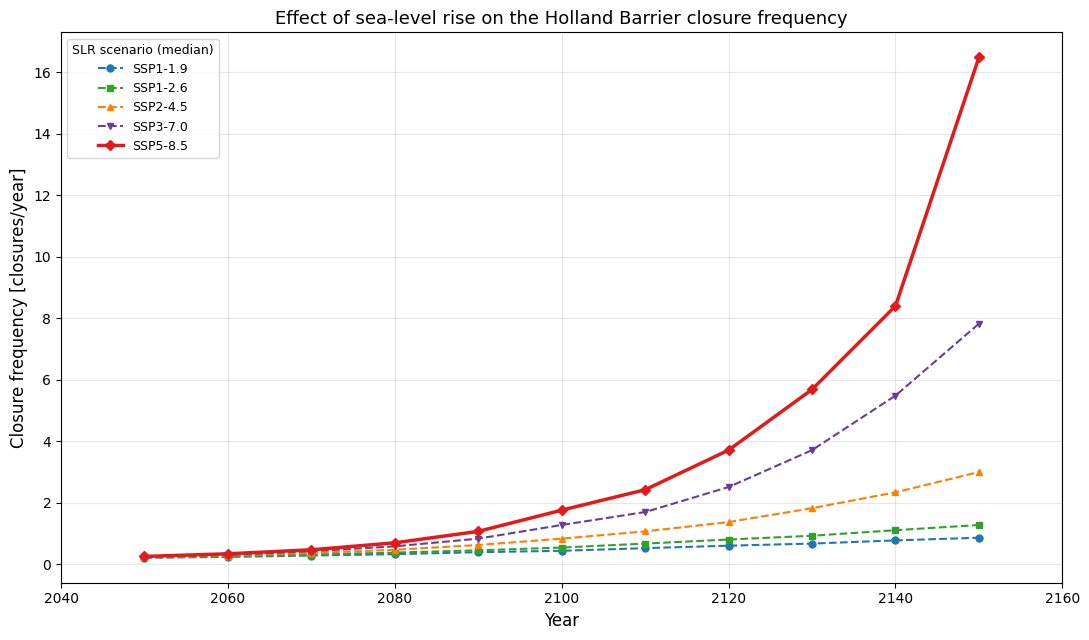

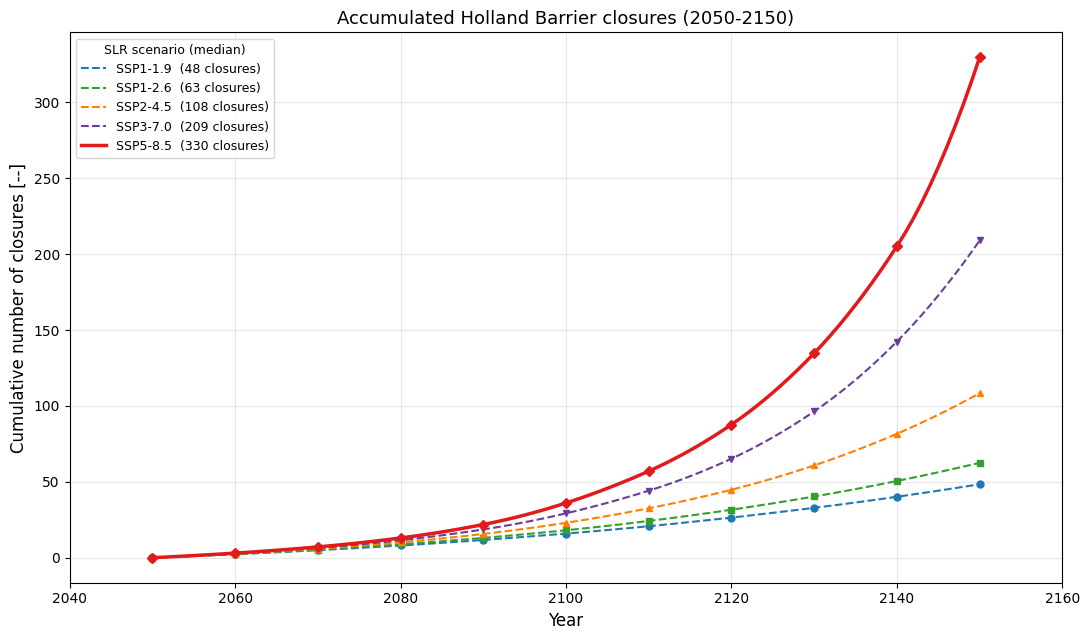


CUMULATIVE CLOSURES BETWEEN 2050 AND 2150

Scenario      SLR 2150 [m]   f (2050) [1/yr]   N_cum [-]   Design value
-----------------------------------------------------------------------
SSP1-1.9              0.57              0.22        48.4             48
SSP1-2.6              0.68              0.23        62.5             63
SSP2-4.5              0.92              0.23       108.4            108
SSP3-7.0              1.19              0.24       209.0            209
SSP5-8.5              1.40              0.26       329.7            330   <-- adopted

Range over all scenarios : 48 - 330 closures
Adopted design value     : 330 closures (SSP5-8.5)


In [ ]:
"""
Closure frequency of the Holland Barrier under sea-level rise.

Return period, closure frequency and cumulative number of closures
are evaluated for five IPCC AR6 sea-level-rise scenarios (median values).
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT
# ============================================================

# Return periods [years]
T = np.array([10, 100, 300, 1000, 3000, 10000])

# Hydra-NL water levels without sea-level rise [m NAP]
WL_base = np.array([3.339, 3.988, 4.299, 4.666, 5.024, 5.444])

# Operational closure level [m NAP]
WL_TARGET = 3.30

# Design life
YEAR_START = 2050
YEAR_END = 2150

# ------------------------------------------------------------
# Sea-level-rise scenarios (median values) [m]
# ------------------------------------------------------------

DECADES = np.array([2050, 2060, 2070, 2080, 2090,
                    2100, 2110, 2120, 2130, 2140, 2150])

SLR_SCENARIOS = {
    "SSP1-1.9": np.array([0.18, 0.21, 0.26, 0.30, 0.35,
                          0.38, 0.43, 0.47, 0.50, 0.54, 0.57]),
    "SSP1-2.6": np.array([0.19, 0.23, 0.29, 0.34, 0.39,
                          0.44, 0.50, 0.55, 0.59, 0.64, 0.68]),
    "SSP2-4.5": np.array([0.20, 0.26, 0.33, 0.40, 0.48,
                          0.56, 0.63, 0.70, 0.78, 0.85, 0.92]),
    "SSP3-7.0": np.array([0.21, 0.28, 0.37, 0.46, 0.56,
                          0.68, 0.76, 0.87, 0.98, 1.09, 1.19]),
    "SSP5-8.5": np.array([0.23, 0.31, 0.40, 0.51, 0.63,
                          0.77, 0.86, 0.98, 1.10, 1.21, 1.40]),
}

# Adopted design scenario (highlighted in the plots)
SCENARIO_DESIGN = "SSP5-8.5"

# Plot styling per scenario
STYLES = {
    "SSP1-1.9": dict(color="#1f78b4", marker="o", linestyle="--", linewidth=1.5),
    "SSP1-2.6": dict(color="#33a02c", marker="s", linestyle="--", linewidth=1.5),
    "SSP2-4.5": dict(color="#ff7f00", marker="^", linestyle="--", linewidth=1.5),
    "SSP3-7.0": dict(color="#6a3d9a", marker="v", linestyle="--", linewidth=1.5),
    "SSP5-8.5": dict(color="#e31a1c", marker="D", linestyle="-", linewidth=2.5),
}


# ============================================================
# FUNCTIONS
# ============================================================

def return_period_at_level(T, WL_curve, WL_target):
    """
    Return period corresponding to a given water level, obtained by
    log-linear extrapolation of the frequency curve through the
    points T = 10 yr and T = 100 yr.
    """
    logT = np.log10(T)
    slope = (WL_curve[1] - WL_curve[0]) / (logT[1] - logT[0])
    logT_target = logT[0] + (WL_target - WL_curve[0]) / slope
    return 10.0 ** logT_target


def cumulative_trapezoid(years, frequency):
    """Cumulative number of closures by trapezoidal integration."""
    N = np.zeros(len(years), dtype=float)
    for i in range(1, len(years)):
        dt = years[i] - years[i - 1]
        N[i] = N[i - 1] + 0.5 * (frequency[i] + frequency[i - 1]) * dt
    return N


def evaluate_scenario(slr_decades):
    """
    Return period, closure frequency (per decade) and the annually
    interpolated cumulative closure count for a single SLR scenario.
    """
    T_close = np.array([
        return_period_at_level(T, WL_base + slr, WL_TARGET)
        for slr in slr_decades
    ])
    frequency = 1.0 / T_close

    years_fine = np.arange(YEAR_START, YEAR_END + 1)
    freq_fine = np.interp(years_fine, DECADES, frequency)
    N_cumulative = cumulative_trapezoid(years_fine, freq_fine)

    return T_close, frequency, years_fine, N_cumulative


# ============================================================
# EVALUATION OF ALL SCENARIOS
# ============================================================

results = {}

for name, slr_decades in SLR_SCENARIOS.items():
    T_close, frequency, years_fine, N_cumulative = evaluate_scenario(slr_decades)
    results[name] = {
        "slr": slr_decades,
        "T_close": T_close,
        "frequency": frequency,
        "years_fine": years_fine,
        "N_cumulative": N_cumulative,
        "N_total": N_cumulative[-1],
    }


# ============================================================
# TABULAR OUTPUT
# ============================================================

def print_table(title, row_labels, columns, fmt):
    """Print a scenario comparison table."""
    print()
    print("=" * 78)
    print(title)
    print("=" * 78)
    header = f"{'Year':<8}" + "".join(f"{n:>13}" for n in SLR_SCENARIOS)
    print(header)
    print("-" * len(header))
    for i, label in enumerate(row_labels):
        line = f"{label:<8}"
        for name in SLR_SCENARIOS:
            line += format(columns[name][i], fmt).rjust(13)
        print(line)


print_table(
    f"RETURN PERIOD OF CLOSURE LEVEL (NAP +{WL_TARGET:.1f} m) [years]",
    [str(y) for y in DECADES],
    {n: results[n]["T_close"] for n in SLR_SCENARIOS},
    ".3f",
)

print_table(
    "CLOSURE FREQUENCY [closures/year]",
    [str(y) for y in DECADES],
    {n: results[n]["frequency"] for n in SLR_SCENARIOS},
    ".2f",
)

idx_decades = [np.where(results[SCENARIO_DESIGN]["years_fine"] == y)[0][0]
               for y in DECADES]

print_table(
    f"CUMULATIVE NUMBER OF CLOSURES SINCE {YEAR_START}",
    [str(y) for y in DECADES],
    {n: results[n]["N_cumulative"][idx_decades] for n in SLR_SCENARIOS},
    ".1f",
)





# ============================================================
# FIGURE 2 - CLOSURE FREQUENCY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

for name in SLR_SCENARIOS:
    ax.plot(DECADES, results[name]["frequency"],
            label=name, markersize=5, **STYLES[name])

ax.set_xlim(2040, 2160)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Closure frequency [closures/year]", fontsize=12)
ax.set_title("Effect of sea-level rise on the Holland Barrier closure frequency",
             fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(title="SLR scenario (median)", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("closure_frequency_scenarios.png", dpi=300)
plt.show()


# ============================================================
# FIGURE 3 - CUMULATIVE CLOSURES
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

for name in SLR_SCENARIOS:
    style = dict(STYLES[name])
    marker = style.pop("marker")
    years_fine = results[name]["years_fine"]
    N_cum = results[name]["N_cumulative"]

    ax.plot(years_fine, N_cum, label=f"{name}  ({N_cum[-1]:.0f} closures)",
            **style)
    ax.plot(DECADES, N_cum[idx_decades], marker, markersize=5,
            color=style["color"], linestyle="none")

ax.set_xlim(2040, 2160)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative number of closures [--]", fontsize=12)
ax.set_title(f"Accumulated Holland Barrier closures ({YEAR_START}-{YEAR_END})",
             fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(title="SLR scenario (median)", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("cumulative_closures_scenarios.png", dpi=300)
plt.show()


# ============================================================
# DESIGN VALUES
# ============================================================

print()
print("=" * 78)
print(f"CUMULATIVE CLOSURES BETWEEN {YEAR_START} AND {YEAR_END}")
print("=" * 78)
print()
print(f"{'Scenario':<12}{'SLR 2150 [m]':>14}{'f (2050) [1/yr]':>18}"
      f"{'N_cum [-]':>12}{'Design value':>15}")
print("-" * 71)

for name in SLR_SCENARIOS:
    r = results[name]
    flag = "   <-- adopted" if name == SCENARIO_DESIGN else ""
    print(f"{name:<12}{r['slr'][-1]:>14.2f}{r['frequency'][0]:>18.2f}"
          f"{r['N_total']:>12.1f}{round(r['N_total']):>15d}{flag}")

N_min = min(results[n]["N_total"] for n in SLR_SCENARIOS)
N_max = max(results[n]["N_total"] for n in SLR_SCENARIOS)

print()
print(f"Range over all scenarios : {round(N_min)} - {round(N_max)} closures")
print(f"Adopted design value     : {round(results[SCENARIO_DESIGN]['N_total'])} "
      f"closures ({SCENARIO_DESIGN})")


**Marginal statistics**

*Wave height*

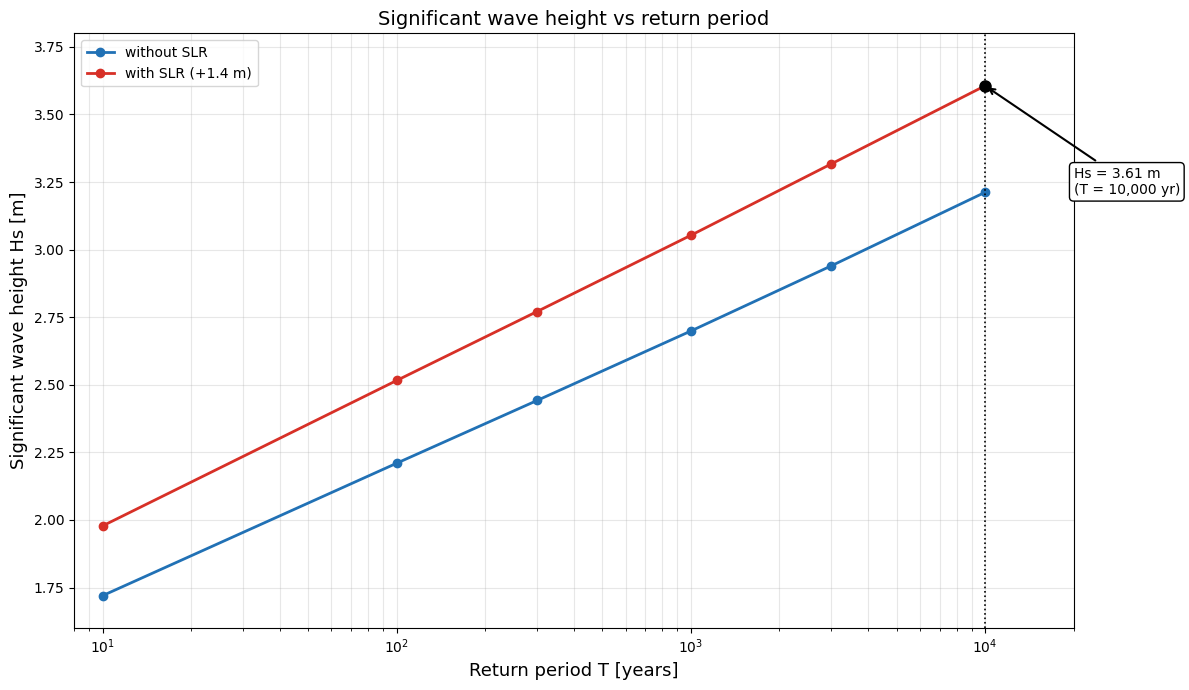


✓ Opgeslagen: hs_return_period_1p4.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Return periods ──
T = np.array([10, 100, 300, 1000, 3000, 10000])

# ── Significant wave heights Hs [m] ──
data = {
    "without SLR":   np.array([1.720, 2.210, 2.442, 2.699, 2.940, 3.212]),
    "with SLR (+1.4 m)": np.array([1.978, 2.516, 2.771, 3.053, 3.317, 3.606]),
}

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#2171b5", "#d73027"]

for i, (scen, hs) in enumerate(data.items()):
    ax.plot(T, hs, '-o',
            color=colors[i],
            linewidth=2,
            markersize=6,
            label=scen)

# ── Verticale lijn T = 10.000 ──
ax.axvline(x=10000, color='black', linestyle=':', linewidth=1.2)

# ── Annotatie hoogste scenario ──
hs_10k = data["with SLR (+1.4 m)"][-1]
ax.plot(10000, hs_10k, 'ko', markersize=8)

ax.annotate(f'Hs = {hs_10k:.2f} m\n(T = 10,000 yr)',
            xy=(10000, hs_10k),
            xytext=(20000, hs_10k - 0.4),
            arrowprops=dict(arrowstyle='->', lw=1.5),
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor='black'))

# ── Opmaak ──
ax.set_xscale('log')
ax.set_xlabel('Return period T [years]', fontsize=13)
ax.set_ylabel('Significant wave height Hs [m]', fontsize=13)
ax.set_title('Significant wave height vs return period',
             fontsize=14)

ax.set_xlim(8, 20000)
ax.set_ylim(1.6, 3.8)

ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('hs_return_period_1p4.png', dpi=200)
plt.show()


**Joint statistics**

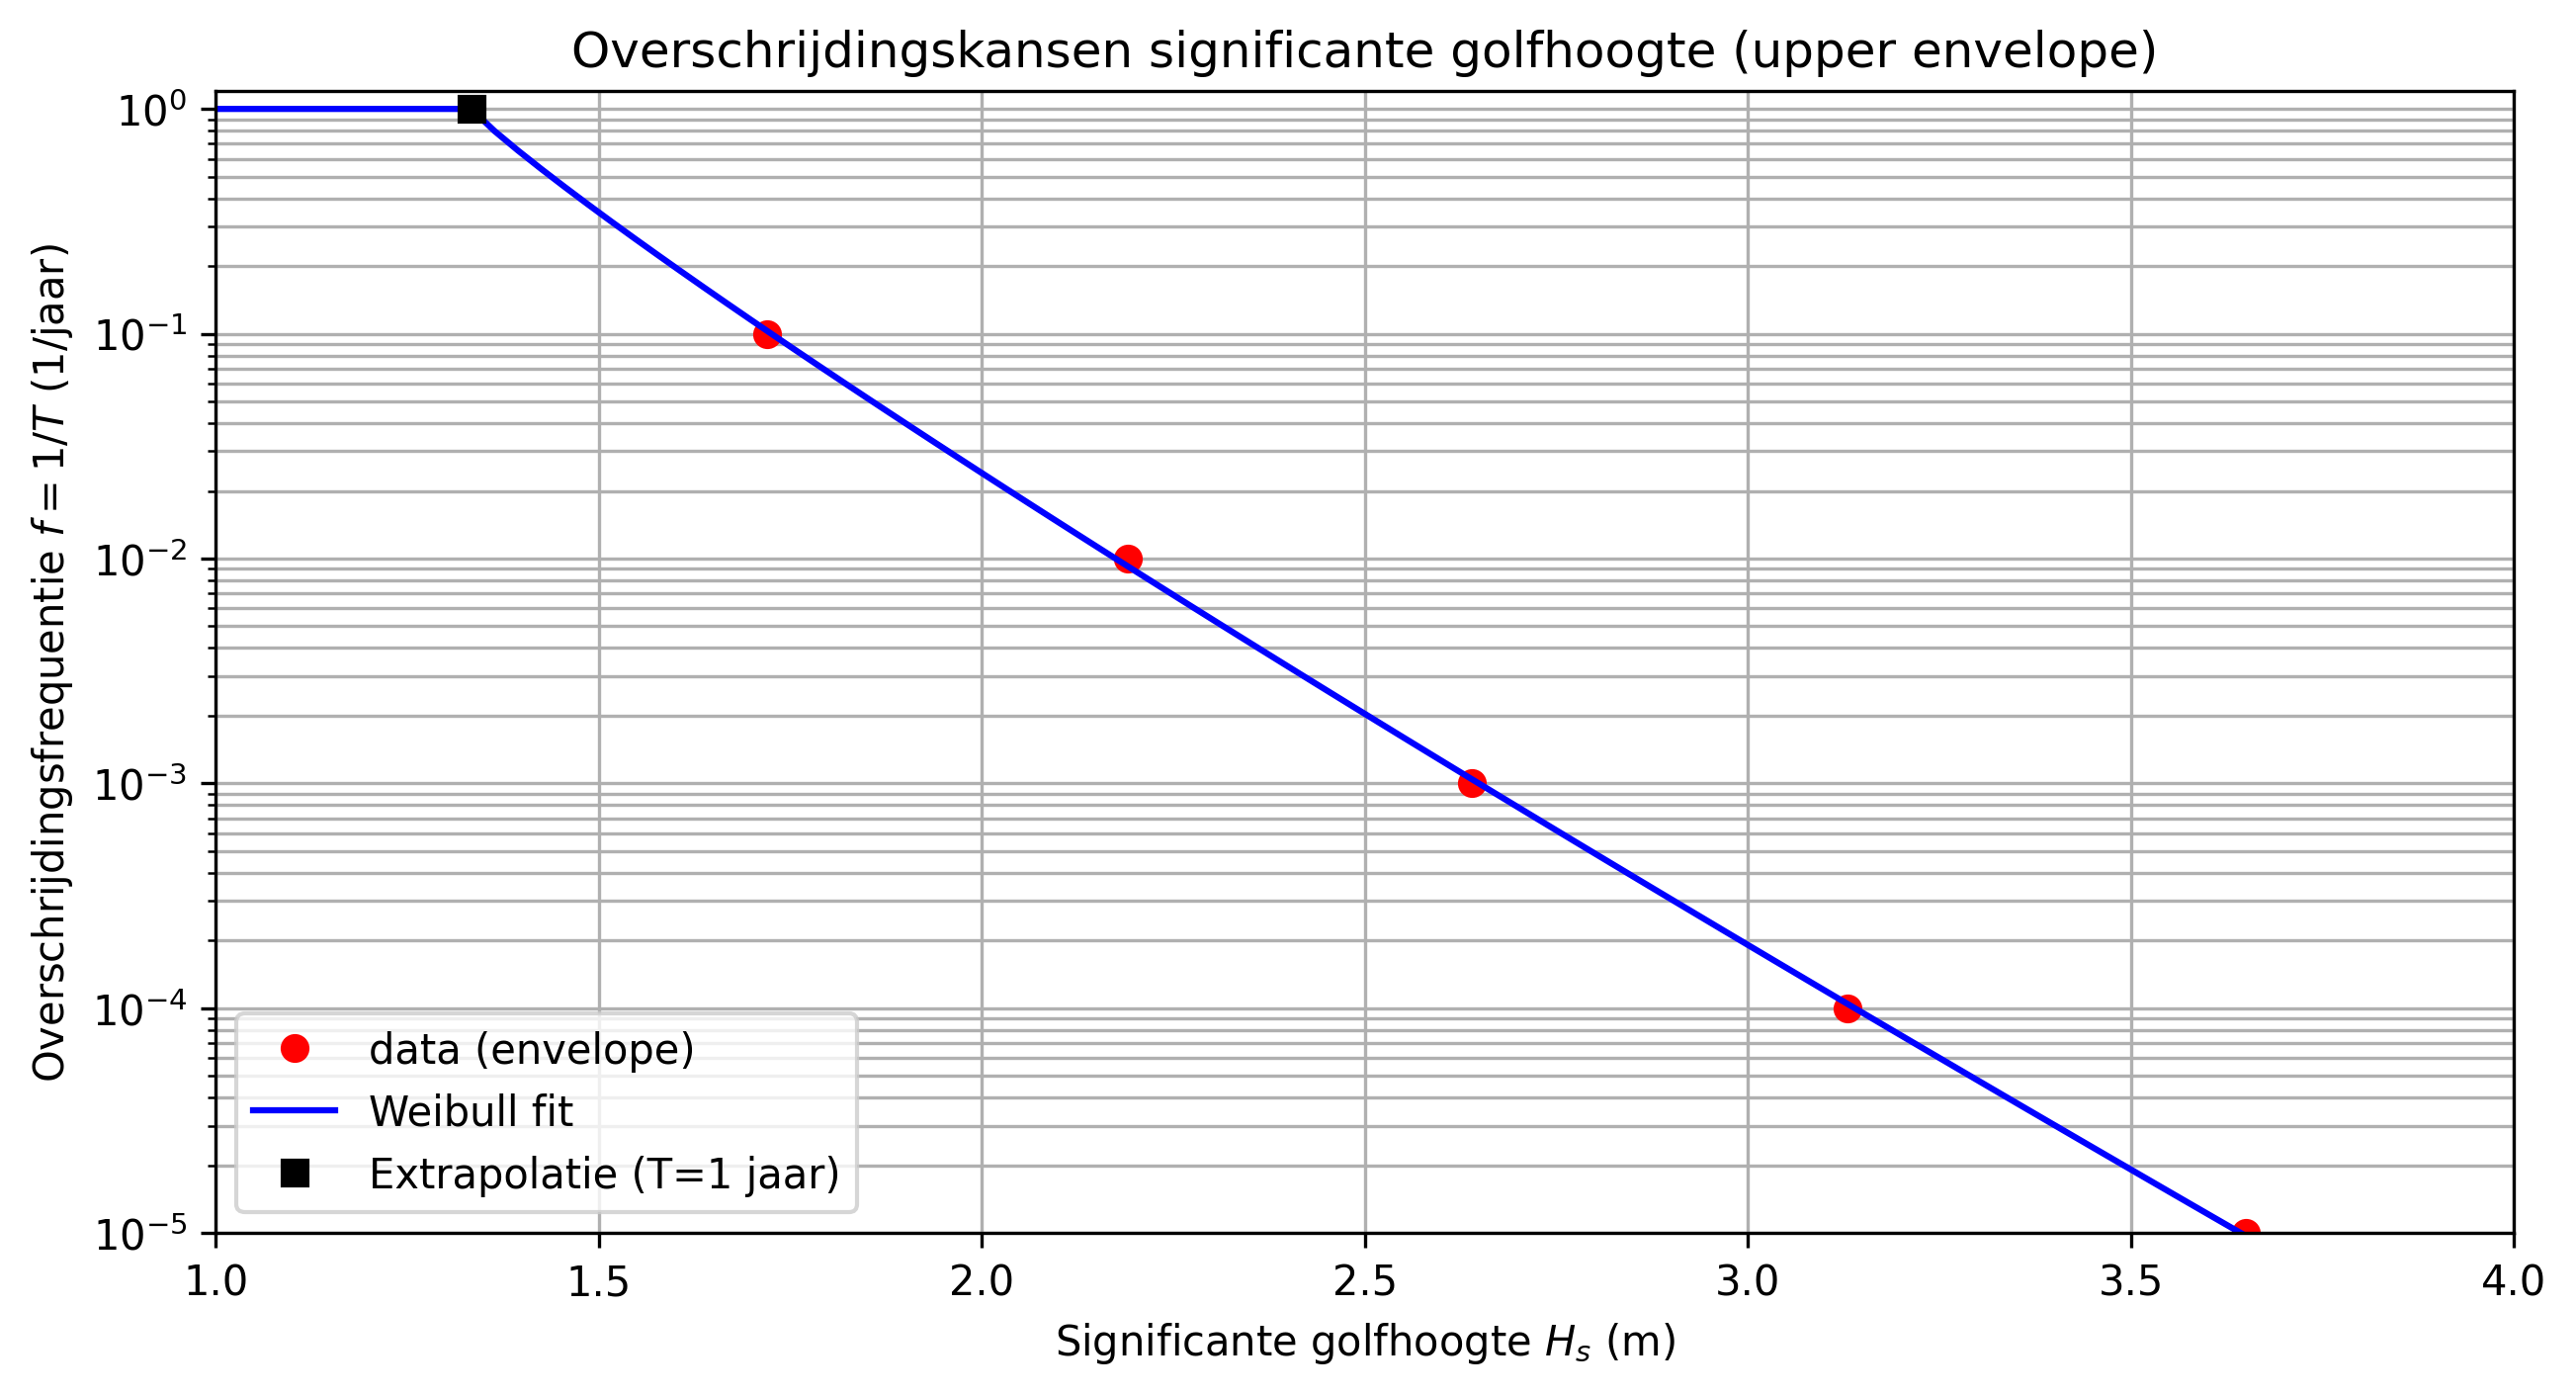

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import quad

EPS = 1e-12

file_path = r"C:\Users\saldenh2867\OneDrive - ARCADIS\Documents\Python\NieuweWaterweg.xlsx"

waterlevel_col     = "Waterstandsniveau [m+NAP]"
Hs_col             = "Golfhoogte [m]"
Tp_col             = "Piekperiode [s]"
return_period_col  = "Terugkeertijd [jaar]"

df = pd.read_excel(file_path)
df["Frequency"] = 1.0 / df[return_period_col]
Freq_col = "Frequency"

df = df[[Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]].dropna()

for col in [Freq_col, Hs_col, Tp_col, waterlevel_col, return_period_col]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce"
    )

df = df.dropna().sort_values(return_period_col).set_index(return_period_col)

env = (
    df.reset_index()
    .dropna(subset=[Hs_col, Tp_col, waterlevel_col, Freq_col])
    .sort_values(Hs_col)
    .drop_duplicates(subset=Freq_col, keep="last")
    .rename(columns={
        return_period_col: "T_return",
        Freq_col: "Freq per jaar",
        waterlevel_col: "WL_at_Hs_upper",
        Hs_col: "Hs (m)",
        Tp_col: "Tp_at_Hs_upper",
    })
)

# Monotone (dalende) frequentie t.o.v. stijgende Hs
env["Freq_mono"] = np.minimum.accumulate(env["Freq per jaar"].to_numpy())

H_env = env["Hs (m)"].to_numpy(float)
p_env = np.clip(env["Freq_mono"].to_numpy(float), EPS, 1 - EPS)


def weibull_exceed_3p(H, a, b, c):
    """3-parameter Weibull-overschrijdingskans: P(H) = exp(-((H-c)/a)^b)."""
    x = np.clip((np.asarray(H, float) - c) / a, 0.0, None)
    return np.exp(-(x ** b))


def resid_envelope(par):
    a, b, c = par
    P_mod = np.clip(weibull_exceed_3p(H_env, a, b, c), EPS, 1 - EPS)
    return np.log(p_env) - np.log(P_mod)


x0     = [np.percentile(H_env, 90), 2.0, H_env.min() - 0.05]
bounds = ([1e-6, 0.3, -1.0], [10 * H_env.max(), 30.0, H_env.min()])
a_env, b_env, c_env = least_squares(
    resid_envelope, x0, bounds=bounds, loss="soft_l1", max_nfev=20000
).x

# Extrapolatie naar T = 1 jaar: bij P=1 geldt H = c
Hs_T1 = c_env
WL_T1 = np.poly1d(np.polyfit(H_env, env["WL_at_Hs_upper"], 1))(Hs_T1)
Tp_T1 = np.poly1d(np.polyfit(H_env, env["Tp_at_Hs_upper"], 1))(Hs_T1)

row_T1 = pd.DataFrame([{
    "T_return": 1.0, "Freq per jaar": 1.0,
    "Hs (m)": Hs_T1, "Tp_at_Hs_upper": Tp_T1, "WL_at_Hs_upper": WL_T1,
}])
cols = ["T_return", "Freq per jaar", "Hs (m)", "Tp_at_Hs_upper", "WL_at_Hs_upper"]
df_waves = (
    pd.concat([row_T1, env[cols]], ignore_index=True)
    .sort_values("T_return")
    .reset_index(drop=True)
    .set_index("T_return")
)

# Controleplot: envelope-fit
H_grid = np.linspace(1.0, 4.0, 100)
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(H_env, p_env, "ro", label="data (envelope)")
plt.plot(H_grid, np.clip(weibull_exceed_3p(H_grid, a_env, b_env, c_env), EPS, 1 - EPS),
         "b-", label="Weibull fit")
plt.plot([Hs_T1], [1.0], "ks", label="Extrapolatie (T=1 jaar)")
plt.yscale("log"); plt.ylim(1e-5, 1.2); plt.xlim(1, 4)
plt.grid(True, which="both")
plt.xlabel("Significante golfhoogte $H_s$ (m)")
plt.ylabel("Overschrijdingsfrequentie $f = 1/T$ (1/jaar)")
plt.legend(loc="lower left")
plt.title("Overschrijdingskansen significante golfhoogte (upper envelope)")
plt.show()